# ❇️ 카테고리 전략 분석

# 0️⃣ 데이터 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from datetime import datetime, timedelta
from scipy.stats import chisquare

sns.set(
    style="white",              # 흰 배경 + 그리드 없음
    font="Malgun Gothic",       # 한글 깨짐 방지
    rc={"axes.unicode_minus": False}  # 마이너스 값 깨지는 거 방지
)  
pd.set_option('display.max_columns', None)  # 전체 출력 O

In [2]:
df = pd.read_csv("merged_df_segment_Final.csv", index_col=False)

date_cols = ['order_purchase_timestamp', 'order_approved_at', 'shipping_limit_date',
             'order_delivered_customer_date', 'order_delivered_carrier_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [3]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state,seller_total_revenue,segment
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9.0,0.0,0,cool_stuff,cool_stuff,27277,volta redonda,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5.0,"Perfeito, produto entregue antes do combinado.",NaN,27277.0,-22.501227,-44.124864,volta redonda,RJ,12271.71,SMB
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3.0,0.0,0,pet_shop,pet_shop,3471,sao paulo,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,3471.0,-23.571687,-46.521540,sao paulo,SP,9178.51,SMB
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14.0,0.0,0,moveis_decoracao,furniture_decor,37564,borda da mata,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,Chegou antes do prazo previsto e o produto sur...,NaN,37564.0,-22.324906,-46.239752,borda da mata,MG,3280.00,SMB
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6.0,0.0,0,perfumaria,perfumery,14403,franca,SP,franca,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,14403.0,-20.545472,-47.381048,franca,SP,1054.82,SMB
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16.0,0.0,0,ferramentas_jardim,garden_tools,87900,loanda,PR,loanda,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,940144190dcba6351888cafa43f3a3a5,5.0,Gostei pois veio no prazo determinado .,NaN,87900.0,-22.939806,-53.148630,loanda,PR,3661.18,SMB


# 1️⃣ 기초 EDA

## Enterprise만 분리

In [4]:
# Enterprise 세그먼트만 분리
df_ent = df[df['segment']=='Enterprise'].copy()

## SMB만 분리

In [5]:
# Enterprise 세그먼트만 분리
df_smb = df[df['segment']=='SMB'].copy()

## 카테고리별 매출 규모 TOP 10

In [6]:
def category_price_top_10 (df, group_name):
    """ 
    카테고리별 매출 규모 상위 10개의 카테고리를 확인하고 시각화 하기 위한 함수

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB
    """
    # 카테고리별 매출 규모 Top 10
    top10_cat_revenue = df.groupby('product_category_name_english')['price'].sum().reset_index().sort_values(by='price', ascending=False).head(10)

    # 시각화
    plt.figure(figsize=(10,8))
    sns.barplot(data=top10_cat_revenue, x='product_category_name_english', y='price',color="#0C29D0")
    plt.xlabel('category')
    plt.ylabel('price')
    plt.title(f'Category revenue - Top 10\n{group_name}')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

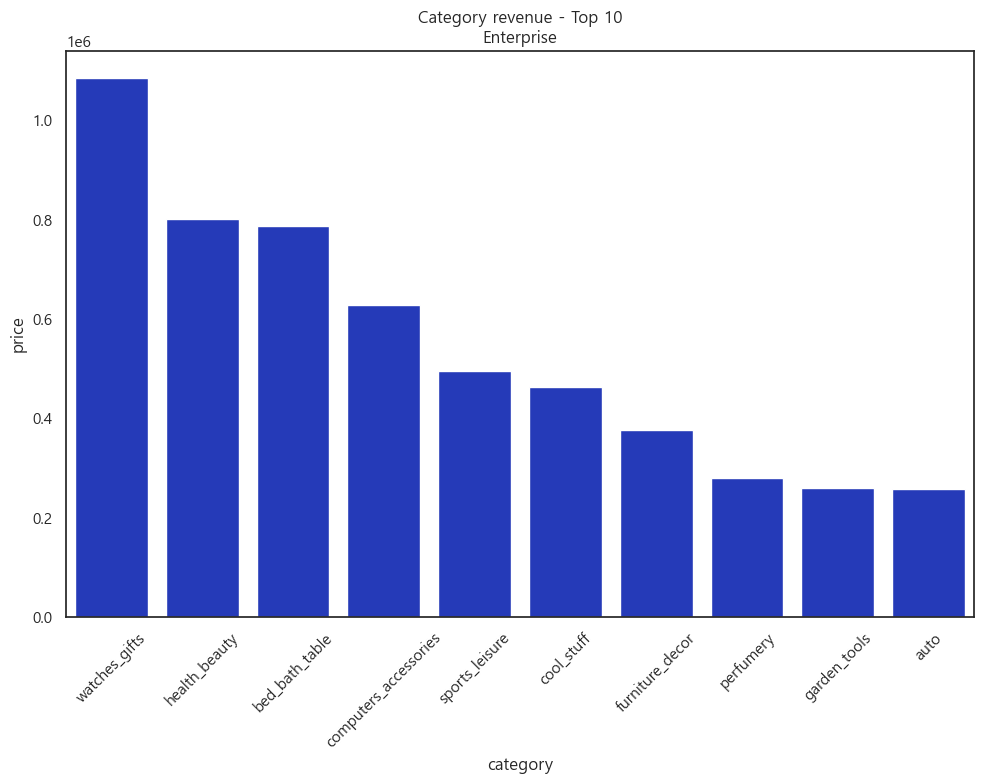

In [7]:
ent_category_price_top_10 = category_price_top_10(df_ent,'Enterprise')
ent_category_price_top_10

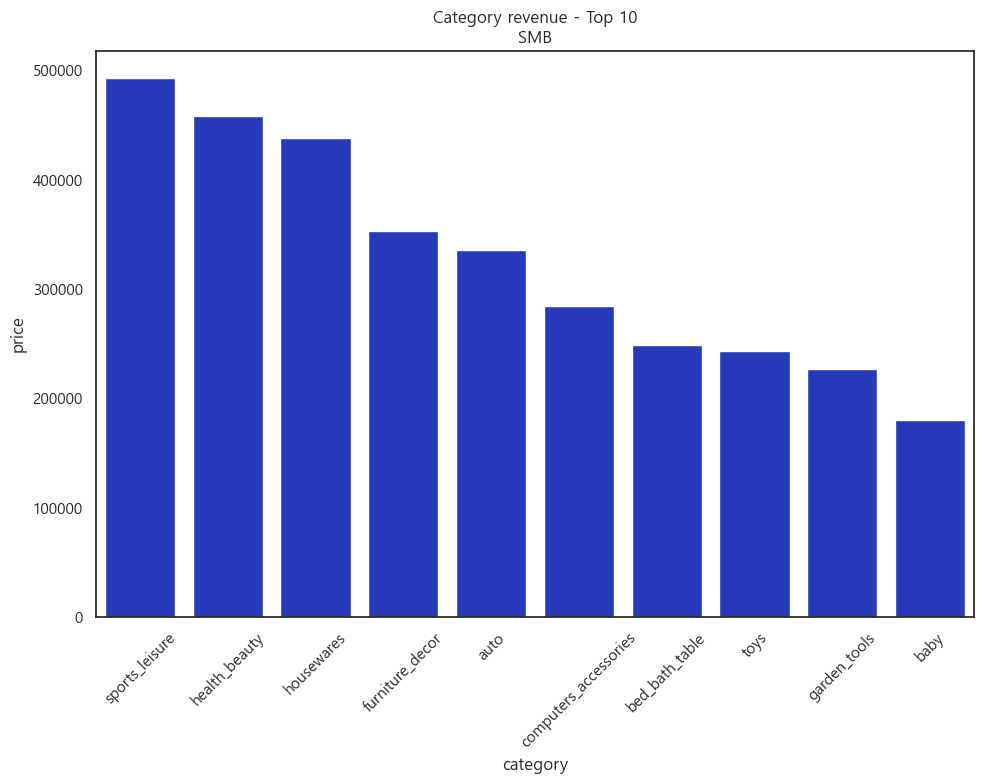

In [8]:
smb_category_price_top_10 = category_price_top_10(df_smb, 'SMB')
smb_category_price_top_10

## 카테고리별 매출 규모 BOTTOM 10

In [9]:
def category_price_bottom_10 (df, group_name):
    """
    카테고리별 매출 규모 하위 10개의 카테고리를 확인하고 시각화 하기 위한 함수

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB
    """
    # 카테고리별 매출(셀러) 규모 Bottom 10
    bottom10_cat_revenue = df.groupby('product_category_name_english')['price'].sum().reset_index().sort_values(by='price', ascending=True).head(10)

    # 시각화
    plt.figure(figsize=(10,8))
    sns.barplot(data=bottom10_cat_revenue, x='product_category_name_english', y='price',color="#0C29D0")
    plt.xlabel('category')
    plt.ylabel('price')
    plt.title(f'Category revenue - Bottom 10\n{group_name}')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

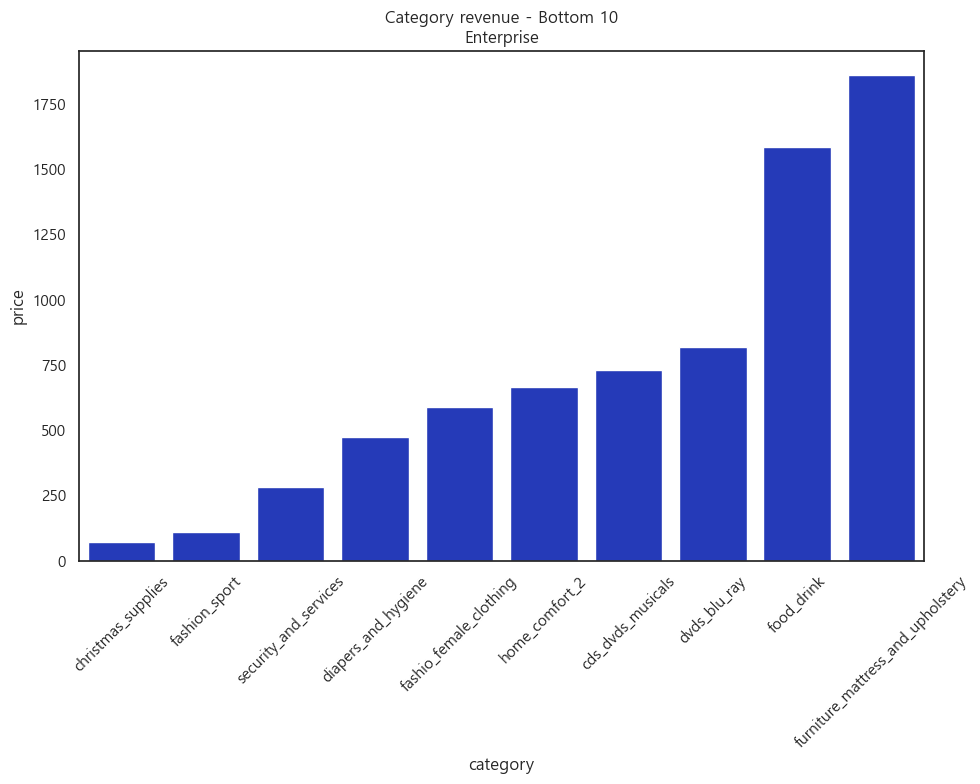

In [10]:
ent_category_price_bottom_10 = category_price_bottom_10(df_ent, 'Enterprise')
ent_category_price_bottom_10

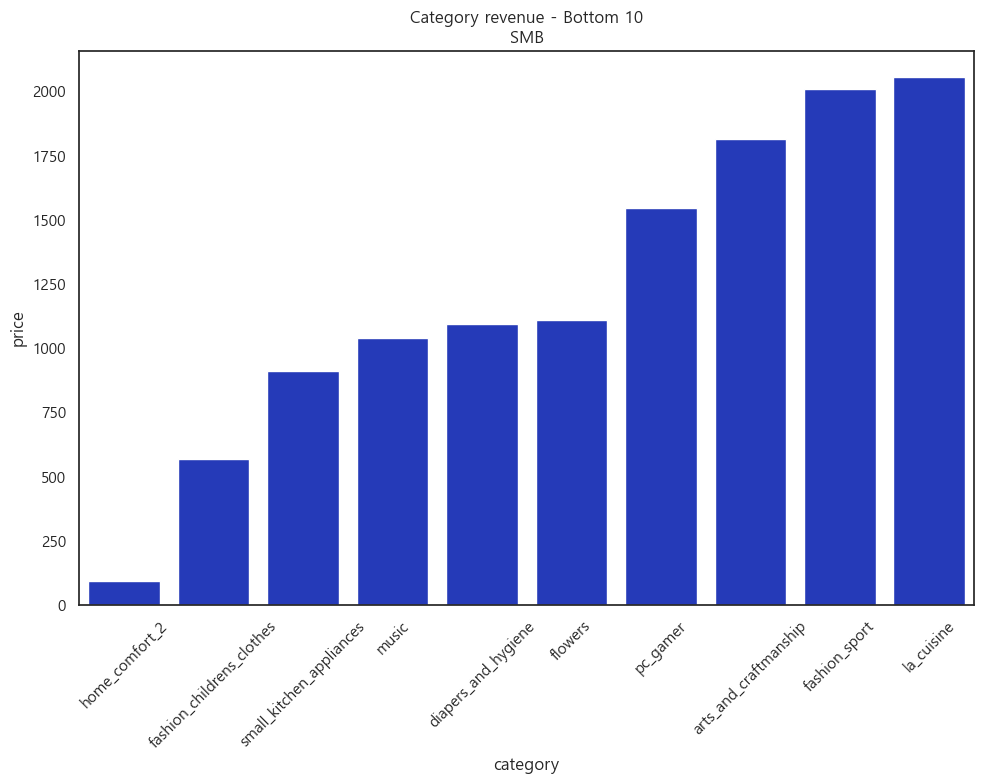

In [11]:
smb_category_price_bottom_10 = category_price_bottom_10(df_smb, 'SMB')
smb_category_price_bottom_10

## 카테고리별 주문 아이템 수 TOP 10

In [12]:
def category_order_item_top_10 (df, group_name):
    """
    카테고리별 주문 아이템 수 상위 10개의 카테고리를 확인하고 시각화 하기 위한 함수

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB
    """
    # 카테고리별 주문 아이템 수 Top 10
    top10_cat_order_item_id_count = df.groupby('product_category_name_english')['order_item_id'].count().reset_index().sort_values(by='order_item_id', ascending=False).head(10)

    # 시각화
    plt.figure(figsize=(10,8))
    sns.barplot(data=top10_cat_order_item_id_count, x='product_category_name_english', y='order_item_id',color="#0C29D0")
    plt.xlabel('category')
    plt.ylabel('order_cnt')
    plt.title(f'Category Order item cnt - Top 10\n{group_name}')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

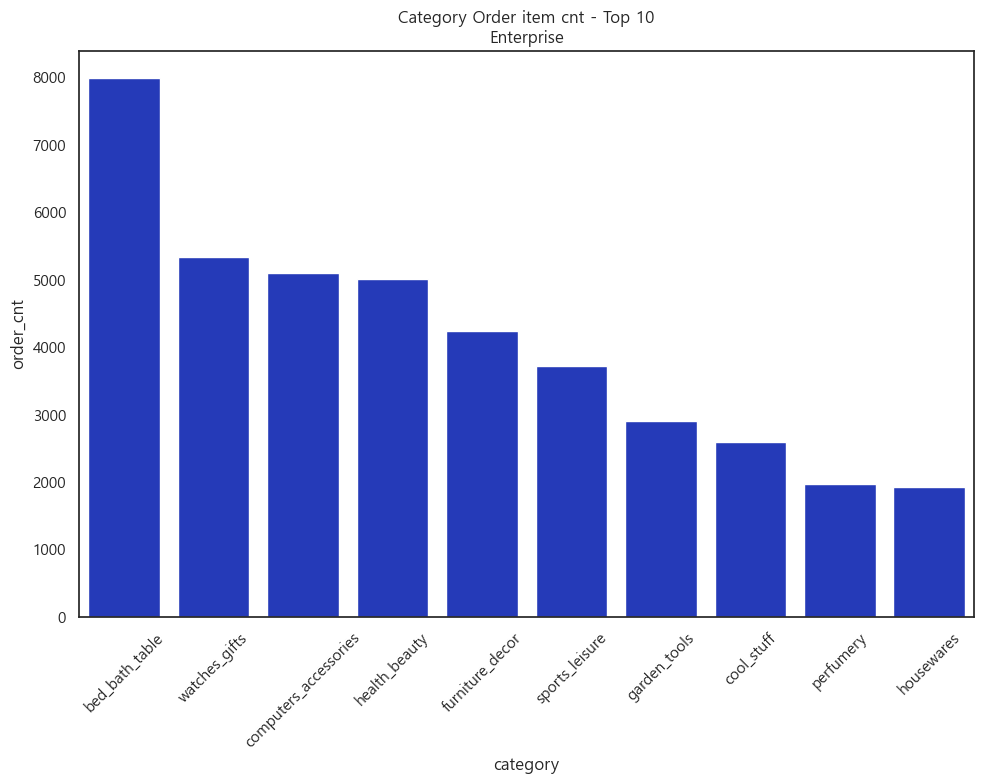

In [13]:
ent_category_order_item_top_10 = category_order_item_top_10(df_ent, 'Enterprise')
ent_category_order_item_top_10

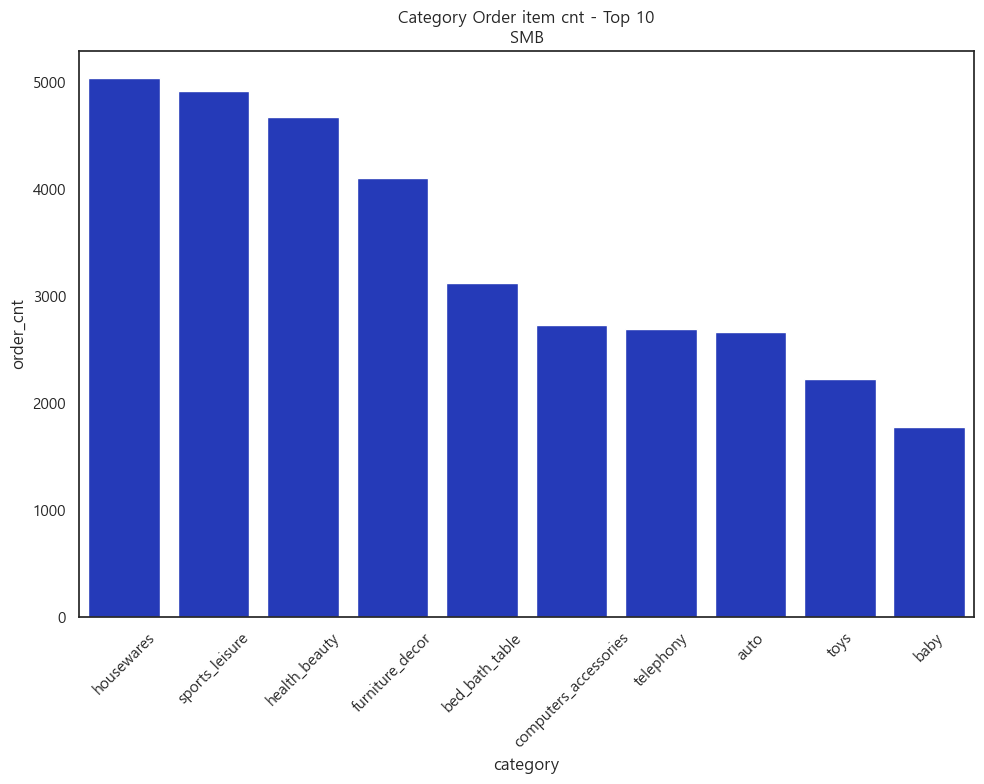

In [14]:
smb_category_order_item_top_10 = category_order_item_top_10(df_smb, 'SMB')
smb_category_order_item_top_10

## 카테고리별 주문 아이템 수 BOTTOM 10

In [15]:
def category_order_item_bottom_10 (df, group_name):
    """
    카테고리별 주문 아이템 수 하위 10개의 카테고리를 확인하고 시각화 하기 위한 함수

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB
    """
    # 카테고리별 총 주문 수 Bottom 10
    bottom10_cat_order_item_id_count = df.groupby('product_category_name_english')['order_item_id'].count().reset_index().sort_values(by='order_item_id', ascending=True).head(10)

    # 시각화
    plt.figure(figsize=(10,8))
    sns.barplot(data=bottom10_cat_order_item_id_count, x='product_category_name_english', y='order_item_id',color="#0C29D0")
    plt.xlabel('category')
    plt.ylabel('order_cnt')
    plt.title(f'Category Order item cnt - Bottom 10\n{group_name}')
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show()

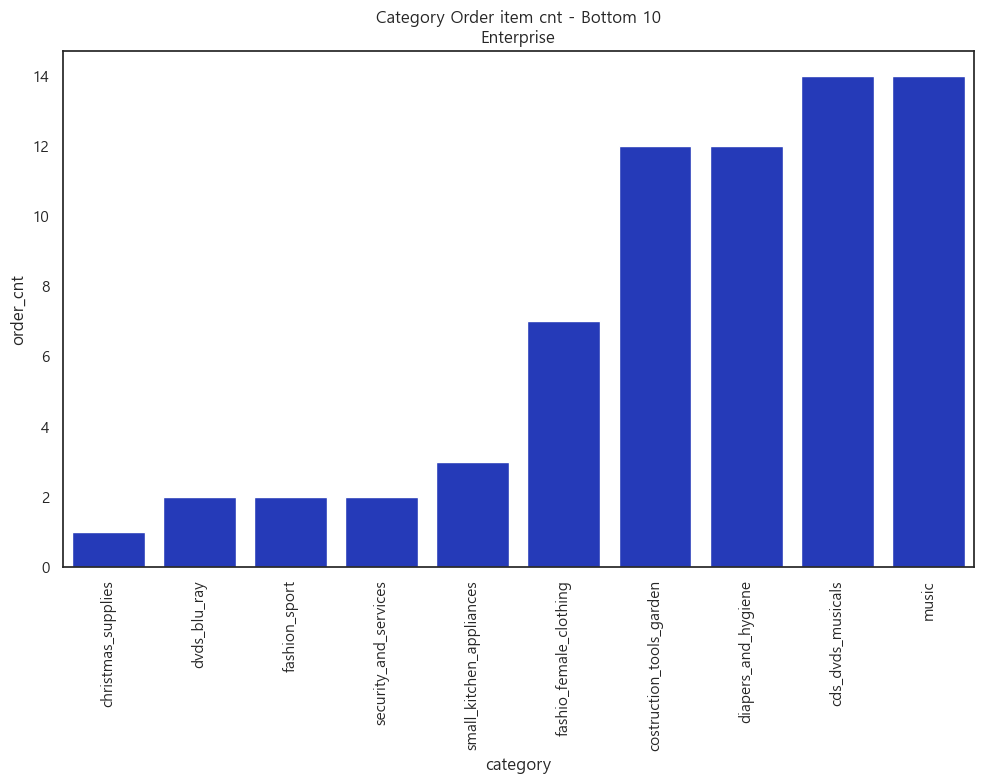

In [16]:
ent_category_order_item_bottom_10 = category_order_item_bottom_10(df_ent, 'Enterprise')
ent_category_order_item_bottom_10

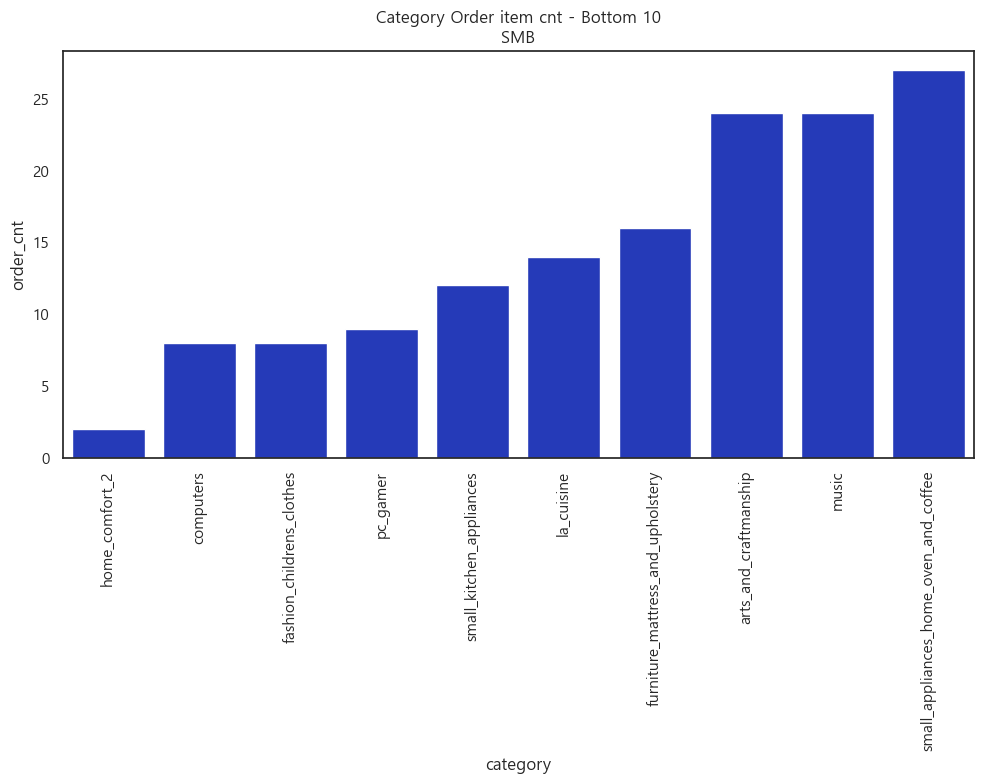

In [17]:
smb_category_order_item_bottom_10 = category_order_item_bottom_10(df_smb, 'SMB')
smb_category_order_item_bottom_10

## 카테고리별 셀러 수 TOP 10

In [18]:
def category_seller_id_top_10 (df, group_name):
    """
    카테고리별 셀러 수 상위 10개 카테고리를 확인하고 시각화 하기 위한 함수

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB
    """
    # 카테고리별 셀러 수 Top 10
    top10_cat_seller_id_nuique = df.groupby('product_category_name_english')['seller_id'].nunique().reset_index().sort_values(by='seller_id', ascending=False).head(10)

    # 시각화
    plt.figure(figsize=(10,8))
    sns.barplot(data=top10_cat_seller_id_nuique, x='product_category_name_english', y='seller_id',color="#0C29D0")
    plt.xlabel('category')
    plt.ylabel('seller_id')
    plt.title(f'Category seller cnt - Top 10\n{group_name}')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

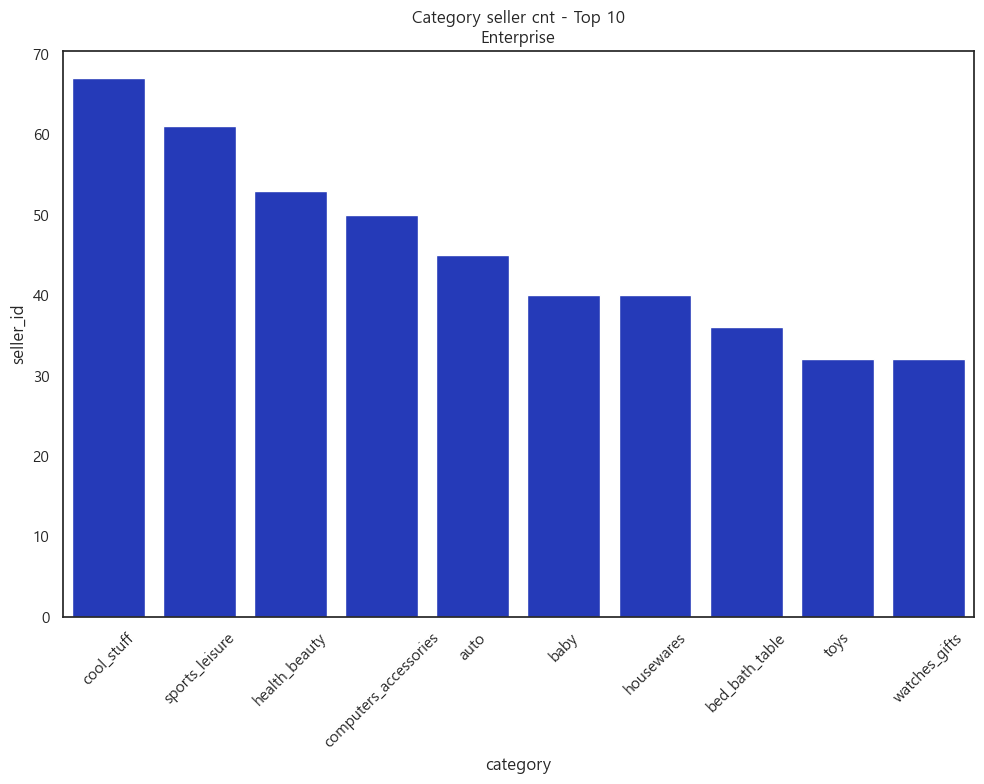

In [19]:
ent_category_seller_id_top_10 = category_seller_id_top_10(df_ent, 'Enterprise')
ent_category_seller_id_top_10

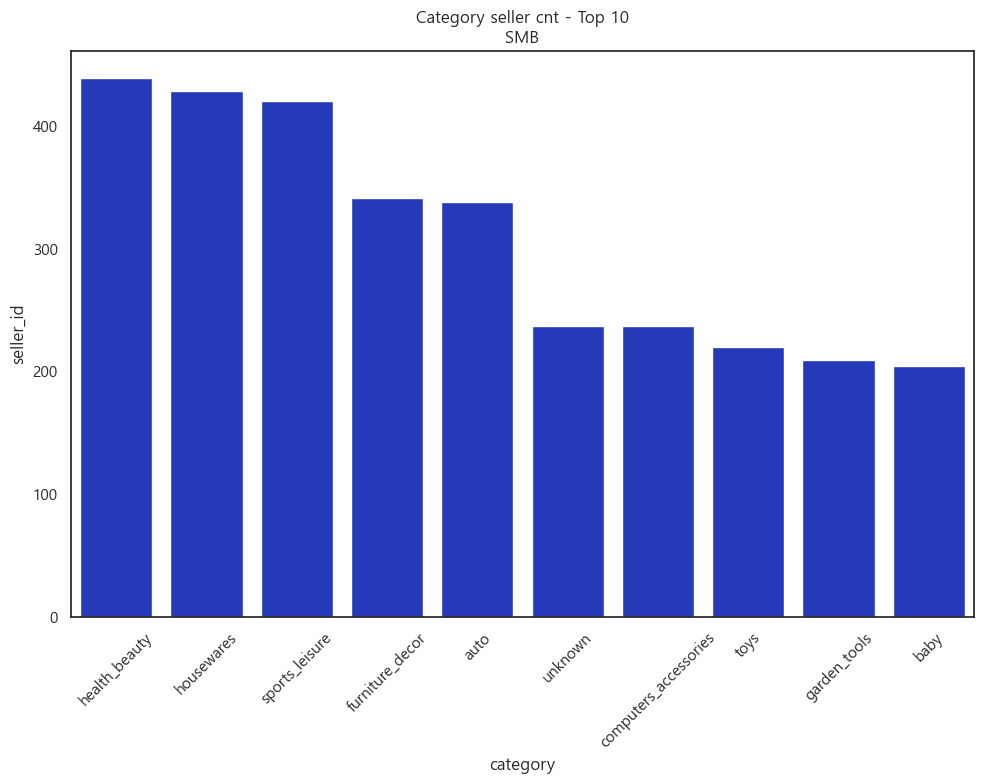

In [20]:
smb_category_seller_id_top_10 = category_seller_id_top_10(df_smb, 'SMB')
smb_category_seller_id_top_10

## 카테고리별 셀러 수 BOTTOM 10

In [21]:
def category_seller_id_bottom_10 (df, group_name):
    """
    카테고리별 셀러 수 하위 10개의 카테고리를 확인하고 시각화 하기 위한 함수

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB
    """
    # 카테고리별 총 셀러 수 Bottom 10
    bottom10_cat_seller_id_nunique = df.groupby('product_category_name_english')['seller_id'].nunique().reset_index().sort_values(by='seller_id', ascending=True).head(10)

    # 시각화
    plt.figure(figsize=(10,8))
    sns.barplot(data=bottom10_cat_seller_id_nunique, x='product_category_name_english', y='seller_id',color="#0C29D0")
    plt.xlabel('category')
    plt.ylabel('seller_id')
    plt.title(f'Category seller cnt - Bottom 10\n{group_name}')
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show()

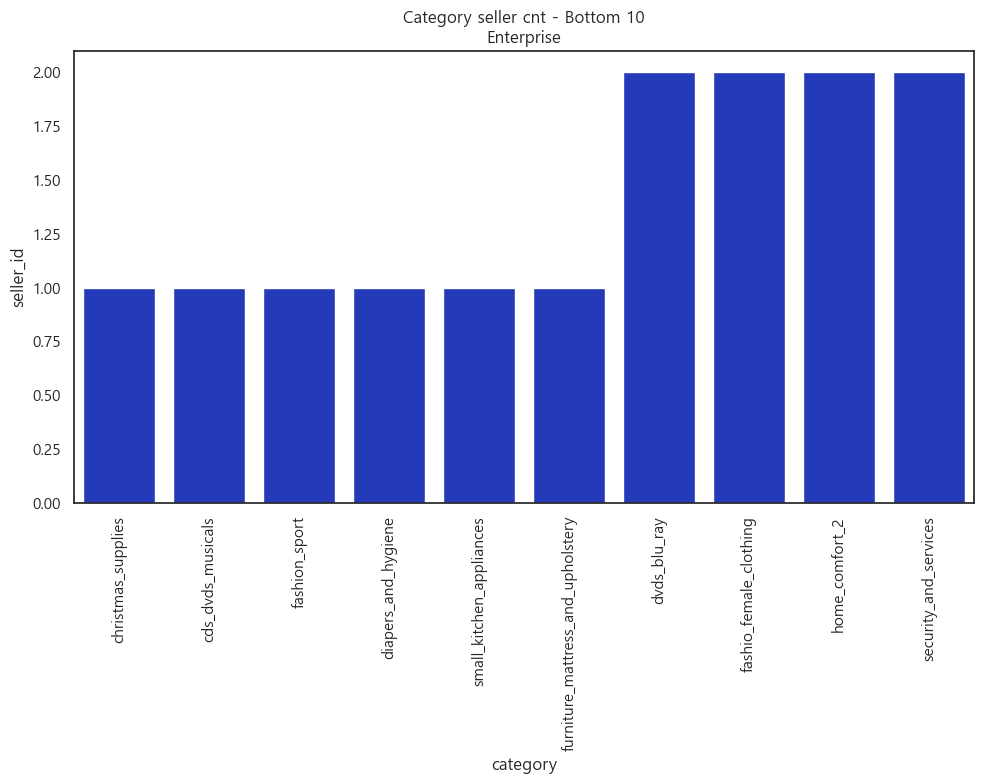

In [22]:
ent_category_seller_id_bottom_10 = category_seller_id_bottom_10(df_ent, 'Enterprise')
ent_category_seller_id_bottom_10

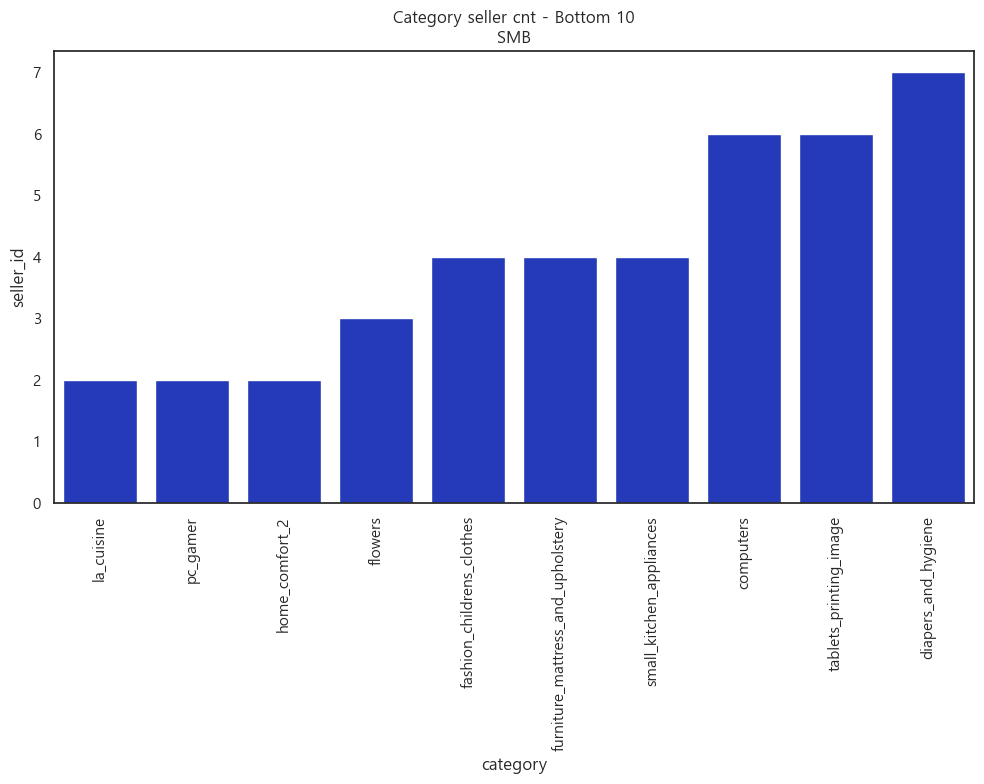

In [23]:
smb_category_seller_id_bottom_10 = category_seller_id_bottom_10(df_smb,'SMB')
smb_category_seller_id_bottom_10

## 카테고리별 셀러당 점유율

In [24]:
def get_seller_share_by_category(df):
    """
    카테고리별 셀러당 점유율을 구하는 함수

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb
    """
    # 카테고리별 각 셀러의 주문수
    cat_seller_order_cnt = (
        df.groupby(['product_category_name_english', 'seller_id'])['order_id']
        .nunique()
        .reset_index()
        .rename(columns={'order_id': 'seller_order_cnt'})
    )

    # 카테고리 전체 주문수 (transform으로 자동 매칭)
    cat_seller_order_cnt['cat_total_order_cnt'] = (
        cat_seller_order_cnt
        .groupby('product_category_name_english')['seller_order_cnt']
        .transform('sum')
    )

    # 카테고리 내 셀러 점유율 (%)
    cat_seller_order_cnt['seller_order_proportion'] = (
        cat_seller_order_cnt['seller_order_cnt'] /
        cat_seller_order_cnt['cat_total_order_cnt'] * 100
    )

    # 정렬
    seller_share_final = cat_seller_order_cnt.sort_values(by=['product_category_name_english', 'seller_order_proportion'], ascending=[True, False]).copy()

    return seller_share_final

In [25]:
ent_seller_share = get_seller_share_by_category(df_ent)
ent_seller_share

,product_category_name_english,seller_id,seller_order_cnt,cat_total_order_cnt,seller_order_proportion
4,agro_industry_and_commerce,e59aa562b9f8076dd550fcddf0e73491,70,93,75.268817
2,agro_industry_and_commerce,955fee9216a65b617aa5c0531780ce60,13,93,13.978495
0,agro_industry_and_commerce,4e922959ae960d389249c378d1c939f5,4,93,4.301075
5,agro_industry_and_commerce,f08a5b9dd6767129688d001acafc21e5,4,93,4.301075
1,agro_industry_and_commerce,634964b17796e64304cadf1ad3050fb7,1,93,1.075269
...,...,...,...,...,...
912,watches_gifts,1f1bb1f0859883505541bdd6606193e5,1,5026,0.019897
917,watches_gifts,4e922959ae960d389249c378d1c939f5,1,5026,0.019897
923,watches_gifts,7299e27ed73d2ad986de7f7c77d919fa,1,5026,0.019897
925,watches_gifts,75d34ebb1bd0bd7dde40dd507b8169c3,1,5026,0.019897


In [26]:
smb_seller_share = get_seller_share_by_category(df_smb)
smb_seller_share

,product_category_name_english,seller_id,seller_order_cnt,cat_total_order_cnt,seller_order_proportion
11,agro_industry_and_commerce,6481e96574816ead57975da2c0f6d80d,13,89,14.606742
25,agro_industry_and_commerce,ef506c96320abeedfb894c34db06f478,12,89,13.483146
23,agro_industry_and_commerce,d9e8c084b68fe958861d8f2c21202e6b,8,89,8.988764
6,agro_industry_and_commerce,31ae0774c17fabd06ff707cc5bde005f,7,89,7.865169
21,agro_industry_and_commerce,d17f467e4bf608a510c20d82f4ba3b6b,7,89,7.865169
...,...,...,...,...,...
5659,watches_gifts,c68fb906c8f4b4b946d8386bfa6e5467,1,634,0.157729
5660,watches_gifts,d624126b9206f595fb3fbb6ba03b28a8,1,634,0.157729
5663,watches_gifts,e5def42655b7490edac5a56fe8e9e603,1,634,0.157729
5664,watches_gifts,e7df4cd29ab5abab70fb0783ddb53987,1,634,0.157729


## 카테고리 점유율 시각화 (독점형, 분산형)

In [27]:
def plot_category_seller_market_share (seller_share, column, group_name, type):
    """
    카테고리 점유율에서 독점형, 분산형 카테고리 예시를 하나씩 시각화 하는 함수 

    args : seller_share : 시각화를 원하는 그룹 테이블
        - Enterprise : ent_seller_share
        - SMB : smb_seller_share

        : column : 필터링을 원하는 카테고리 이름

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB

        : type :그래프 제목에 넣을 타입 이름
        - 독점 : monopoly
        - 분산 : fragmented
    """
    # 카테고리 필터 
    df_plot_m = (
        seller_share[
            seller_share['product_category_name_english'] 
            == column
        ]
        .sort_values(by='seller_order_proportion', ascending=False)
    )

    # 막대그래프 시각화
    plt.figure(figsize=(10, 8))
    plt.bar(
        df_plot_m['seller_id'], 
        df_plot_m['seller_order_proportion'],
        color="#0C29D0"
    )

    plt.xlabel('Seller ID')
    plt.ylabel('Seller Order Proportion')
    plt.title(f'Seller Order Proportion by Seller - {group_name}\ntype : {type}\ncategory name : {column}')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Enterprise 그룹 독점형 카테고리 예시 시각화

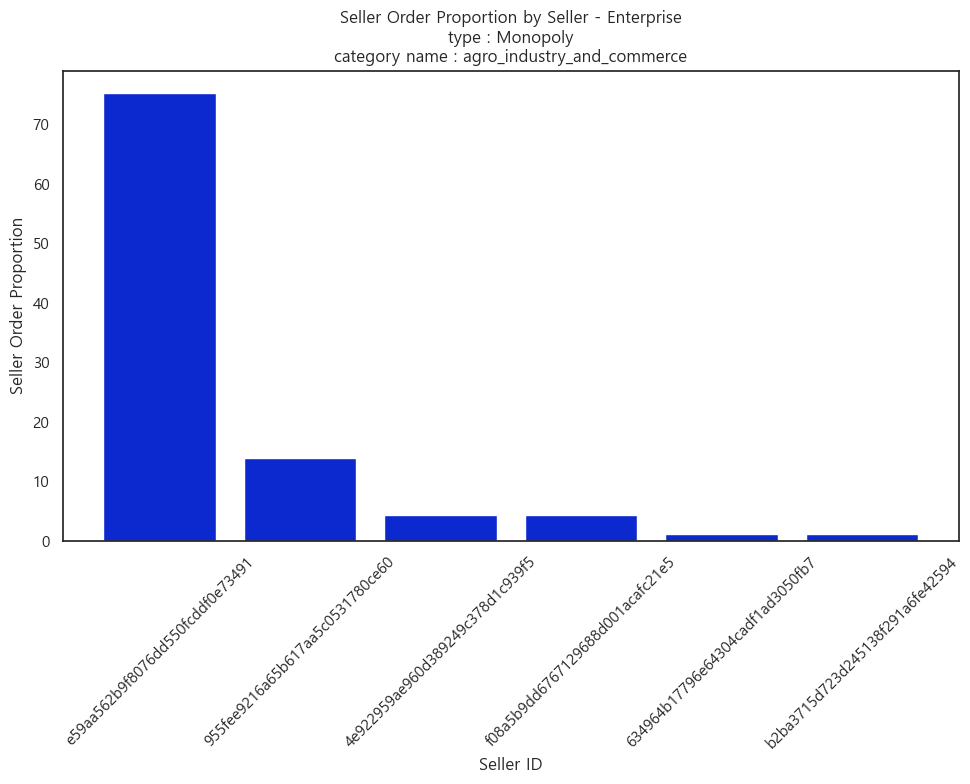

In [28]:
monopoly_ent = plot_category_seller_market_share(ent_seller_share, 'agro_industry_and_commerce', 'Enterprise', 'Monopoly')
monopoly_ent

### SMB 그룹 독점형 카테고리 예시 시각화

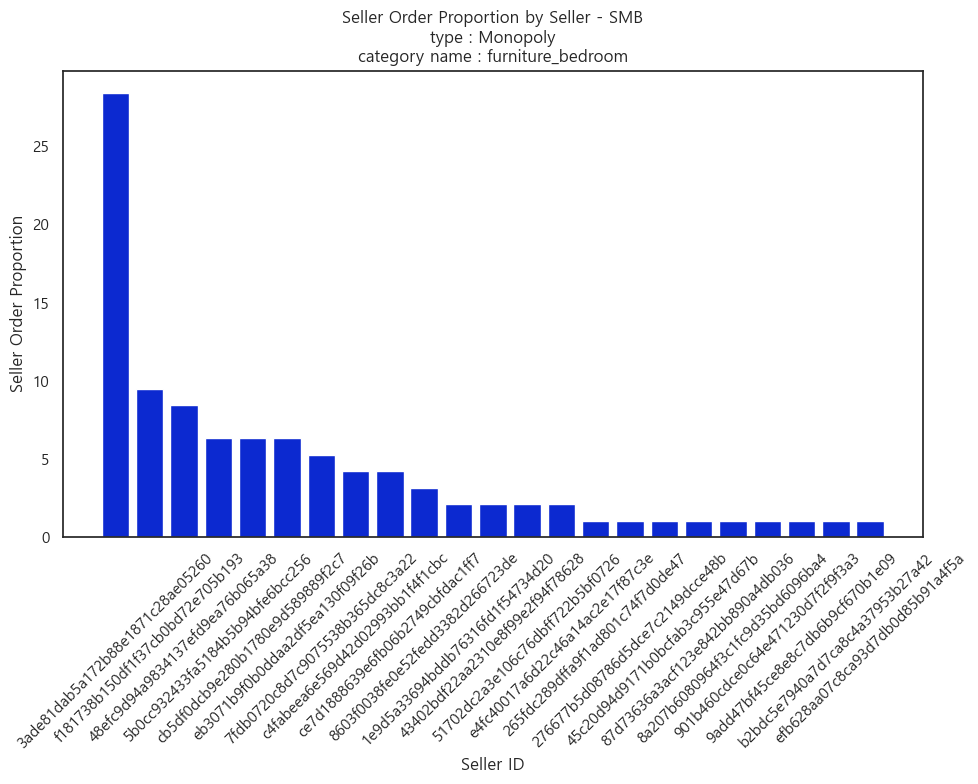

In [29]:
monopoly_smb = plot_category_seller_market_share(smb_seller_share, 'furniture_bedroom', 'SMB', 'Monopoly')
monopoly_smb

Enterprise 그룹 분산형 카테고리 예시 시각화

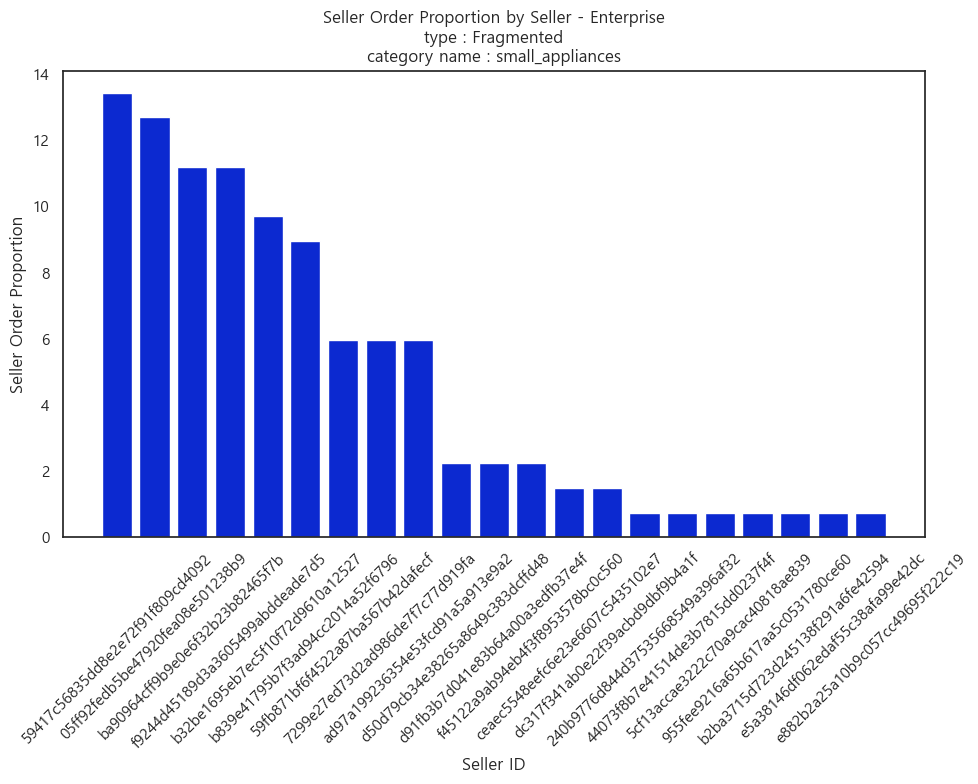

In [30]:
fragmented_ent = plot_category_seller_market_share(ent_seller_share, 'small_appliances', 'Enterprise', 'Fragmented')
fragmented_ent

SMB 그룹 분산형 카테고리 예시 시각화

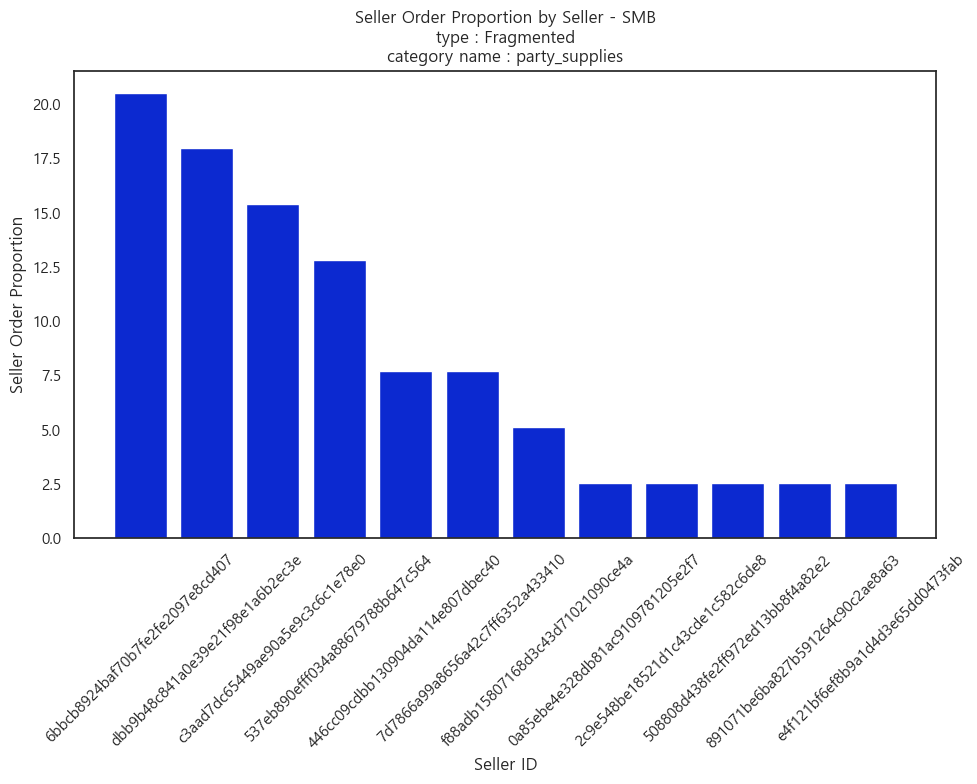

In [31]:
fragmented_smb = plot_category_seller_market_share(smb_seller_share, 'party_supplies', 'SMB', 'Fragmented')
fragmented_smb

## 지역별 셀러 수

In [32]:
def region_seller_cnt(df, group_name):
    """
    주 단위 지역별 셀러 수를 비교하고 시각화 하기 위한 함수

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB
    """
    # 지역(주 단위)별 셀러수 구하기
    state_seller_count = df.groupby('seller_state')['seller_id'].nunique().sort_values(ascending=False).reset_index()

    # 시각화
    plt.figure(figsize=(10,5))
    sns.barplot(data=state_seller_count, x='seller_state', y='seller_id',color="#0C29D0")
    plt.xlabel('seller_state')
    plt.ylabel('seller_cnt')
    plt.title(f'Seller cnt by region - {group_name}')
    plt.tight_layout()
    plt.show()

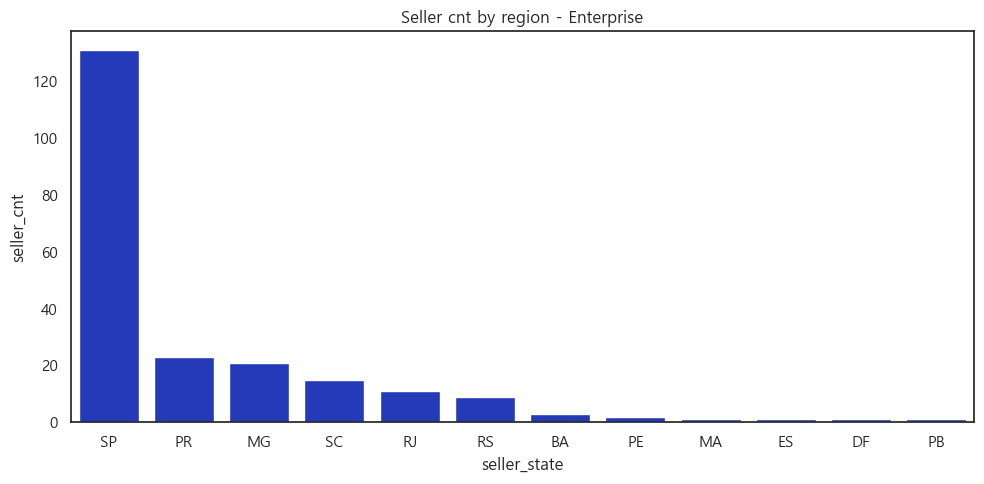

In [33]:
ent_region_seller_cnt = region_seller_cnt(df_ent, 'Enterprise')
ent_region_seller_cnt

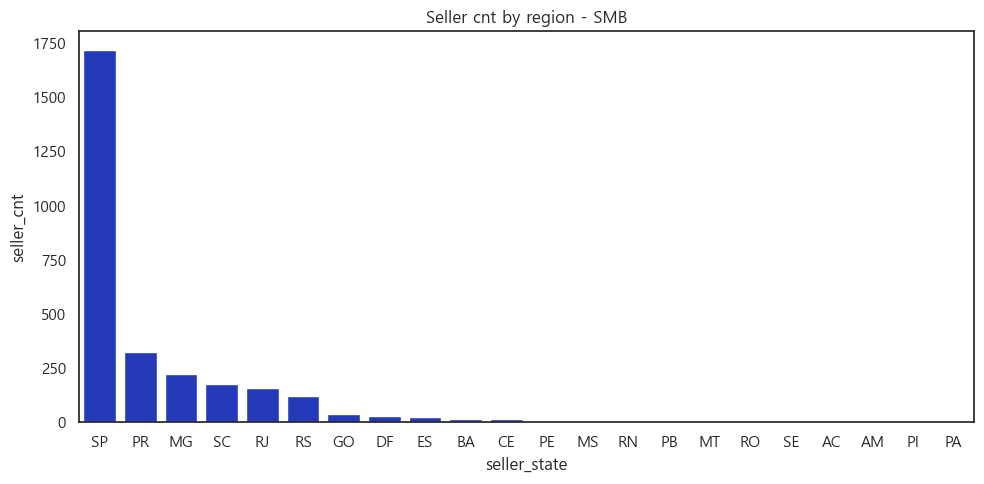

In [34]:
smb_region_seller_cnt = region_seller_cnt(df_smb, 'SMB')
smb_region_seller_cnt

## 지역별 인기도

In [35]:
def region_order_cnt (df, group_name):
    """
    주 단위 지역별 주문 수로 주문이 많이 들어오는 주가 어디인지 확인하고 시각화 하는 함수
    즉, 인기가 많은 지역이 어디인지 확인

    args : df : 시각화를 원하는 그룹 테이블
        - Enterprise : df_ent
        - SMB : df_smb

        : group_name : 그래프 제목에 넣을 그룹 이름
        - Enterprise : Enterprise
        - SMB : SMB
    """
    # 고객 지역별 주문수 구하기
    customer_state_order_count = df.groupby('customer_state')['order_id'].nunique().sort_values(ascending=False).reset_index()

    # 시각화
    plt.figure(figsize=(10,5))
    sns.barplot(data=customer_state_order_count, x='customer_state', y='order_id',color="#0C29D0")
    plt.xlabel('customer_state')
    plt.ylabel('order_cnt')
    plt.title(f'Order cnt by region - {group_name}')
    plt.tight_layout()
    plt.show()

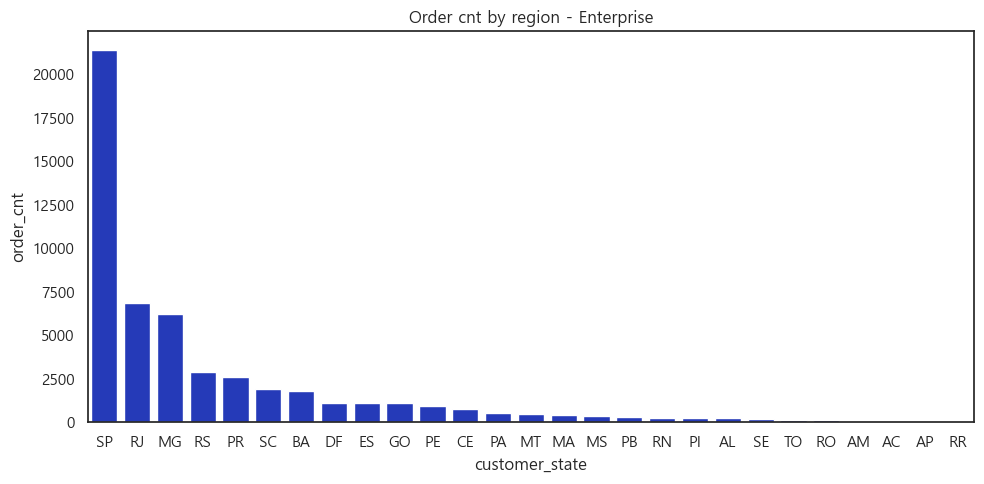

In [36]:
ent_region_order_cnt = region_order_cnt(df_ent, 'Enterprise')
ent_region_order_cnt

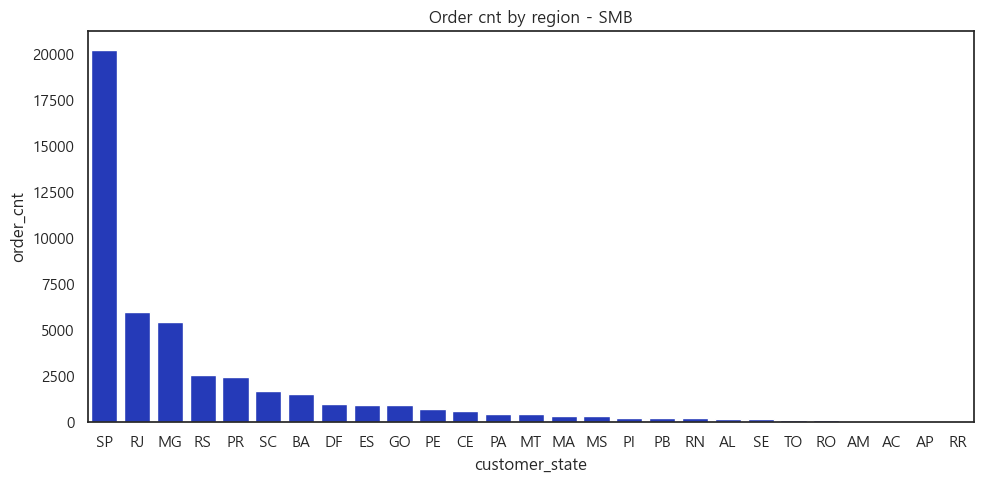

In [37]:
smb_region_order_cnt = region_order_cnt(df_smb, 'SMB')
smb_region_order_cnt

# 2️⃣ 통계 분석

#### order_id를 수요로 봤을 때
- 카테고리별 주문 수의 합과 전체 주문 수의 합이 안 맞음
    - 그 이유 : 한 주문에 여러 개의 상품을 주문 한 경우, 합이 맞지 않음.
    - 예를 들어, 2개의 상품을 주문 했다고 가정했을 때, 각각 다른 카테고리에서 제품을 구매했다면 주문 수는 1개지만 카테고리별 주문 수는 2개가 됌.
- 즉, df['order_id'].nunique()는 수요로 보기에 적절하지 않다.

In [38]:
# 전체 셀러 수
total_seller_cnt_1 = df['seller_id'].nunique()

# 카테고리별 order_id
cat_order_count_1 = df.groupby('product_category_name_english')['order_id'].nunique()

# 전체 order_id
total_order_cnt_1 = df['order_id'].nunique()

# 카테고리별 수요 비중
cat_demand_ratio_1 = (cat_order_count_1 / total_order_cnt_1)

# 기대공급량
# 전체 셀러 수 * 카테고리별 주문 수 /전체 주문 수
expected_supply_1 = cat_demand_ratio_1 * total_seller_cnt_1

# 실제 공급량
# 카테고리별 실존 셀러 수
actual_supply_1 = df.groupby('product_category_name_english')['seller_id'].nunique()

In [39]:
print(total_seller_cnt_1) # 전체 셀러 수
print(cat_order_count_1.sum()) # 카테고리별 주문 수의 합
print(total_order_cnt_1) # 전체 주문 수
print(cat_demand_ratio_1.sum()) # 카테고리별 수요 비중 합

3095
99470
98666
1.0081487037074575


#### order_item_id를 수요로 봤을 때
- 카테고리별 주문 아이템 수의 합과 전체 주문 아이템 수가 동일함.
- 즉, df['order_item_id'].count()를 수요로 보는 게 적절하다.

In [40]:
# 전체 셀러 수
total_seller_cnt = df['seller_id'].nunique()

# 카테고리별 order_item_id
cat_order_count = df.groupby('product_category_name_english')['order_item_id'].count()

# 전체 order_item_id
total_order_cnt = df['order_item_id'].count()

# 카테고리별 수요 비중
cat_demand_ratio = (cat_order_count / total_order_cnt)

# 기대공급량
# 전체 셀러 수 * 카테고리별 주문 수 /전체 주문 수
expected_supply = cat_demand_ratio * total_seller_cnt

# 실제 공급량
# 카테고리별 실존 셀러 수
actual_supply = df.groupby('product_category_name_english')['seller_id'].nunique()

In [41]:
print(total_seller_cnt) # 전체 셀러 수
print(cat_order_count.sum()) # 카테고리별 order_item_id 수의 합
print(total_order_cnt) # 전체 order_item_id 수 
print(cat_demand_ratio.sum()) # 카테고리별 수요 비중 합 

3095
112650
112650
1.0


### Enterprise 그룹 분리

In [42]:
# Enterprise 세그먼트만 분리
df_ent = df[df['segment']=='Enterprise'].copy()

### SMB 그룹 분리

In [43]:
# SMB 세그먼트만 분리
df_smb = df[df['segment']=='SMB'].copy()

## 1. 수요 대비 공급 적정성 검정

In [44]:
def supply_demand_chi_test (df):
    """
    카이제곱 적합도 검정을 위한 함수

    args : df 
        - Enterprise : df_ent
        - SMB  : df_smb
    """

    # 카테고리별 주문 아이템 수
    cat_order_item_count = df.groupby('product_category_name_english')['order_item_id'].count()

    # 전체 주문 아이템 수
    total_order_item_cnt = df['order_item_id'].count()

    # 카테고리별 수요 비중
    cat_demand_ratio = (cat_order_item_count / total_order_item_cnt) * 100

    # 실제 공급량
    actual_supply = df.groupby('product_category_name_english')['seller_id'].nunique()

    # 실제 공급량의 합 = 전체 공급량 
    total_supply = actual_supply.sum()

    # 기대공급량 (비율 기준)
    expected_supply = cat_demand_ratio * total_supply / 100


    # 하나의 데이터프레임으로 만들기
    df_expected_actual = pd.DataFrame({
        'category': cat_order_item_count.index,
        'expected_supply': expected_supply.values,
        'actual_supply': actual_supply.values
    })

    # expected가 작은 카테고리 식별
    # expected가 5보다 작으면 통계적으로 유의하지 않음.
    # expected < 5 인 카테고리는 검정에서 제와
    # 5보다 작은 카테고리는 Other 
    small = df_expected_actual[df_expected_actual['expected_supply'] < 5]['category'].tolist()
    large_df = df_expected_actual[df_expected_actual['expected_supply'] >= 5].copy()

    # 'Other'로 합치기 (작은 것들 합산)
    other_expected = df_expected_actual[df_expected_actual['category'].isin(small)]['expected_supply'].sum()
    other_actual = df_expected_actual[df_expected_actual['category'].isin(small)]['actual_supply'].sum()

    # Other 행 만들기
    other_row = pd.DataFrame([{
        'category': 'Other',
        'expected_supply': other_expected,
        'actual_supply': other_actual
    }])

    
    # 기대값 합계 스케일링
    # 기대 공급량의 합 == 실제 공급량의 합 이여야 카이제곱 적정성 검정 가능
    scale_factor = large_df['actual_supply'].sum() / large_df['expected_supply'].sum()
    large_df['expected_supply_scaled'] = large_df['expected_supply'] * scale_factor

    # 관측값과 기대값 배열로 변환
    obs = large_df['actual_supply'].astype(float).to_numpy()
    exp = large_df['expected_supply_scaled'].astype(float).to_numpy()

    # 카이제곱 적합도 검정
    chisq_stat, p_value = chisquare(
        f_obs=obs,
        f_exp=exp
    )

    # 카이제곱 적합도 결과 확인
    print(f"Chi-squared Statistic: {chisq_stat}")
    print(f"p-value: {p_value}")

    # 카이제곱 적합도 결과 해석
    if p_value < 0.05:
        print("\n공급 분포가 수요 비중과 통계적으로 유의하게 다릅니다.")
    else:
        print("\n공급 분포가 수요 비중과 통계적으로 유의하게 다르지 않습니다.")

    

In [45]:
# Enterprise 
res_ent = supply_demand_chi_test(df_ent)

Chi-squared Statistic: 294.6895701956129
p-value: 1.963102381391776e-48

공급 분포가 수요 비중과 통계적으로 유의하게 다릅니다.


In [46]:
# SMB
res_smb = supply_demand_chi_test(df_smb)

Chi-squared Statistic: 1004.3415174252641
p-value: 6.606418561842534e-174

공급 분포가 수요 비중과 통계적으로 유의하게 다릅니다.


## HHI와 셀러 대비 주문 아이템 수 매트릭스

### HHI (시장 집중도)
- HHI < 1500 : 경쟁적 시장
- 1500 ~ 2500 : 중간 집중 시장
- HHI > 2500 : 고도로 집중된 시장

In [47]:
def calculate_HHI(df):
    """
    카테고리별 셀러 집중도 HHI 계산 함수
    - 기준 : 주문 아이템 수

    args : df 
        - Enterprise : df_ent
        - SMB  : df_smb
    """

    # 카테고리별 각 셀러의 주문 아이템 수
    cat_seller_order_item_cnt = (
        df.groupby(['product_category_name_english', 'seller_id'])['order_item_id']
        .count()
        .reset_index()
        .rename(columns={'order_item_id': 'seller_order_item_cnt'})
    )

    # 카테고리별 전체 주문 아이템 수
    cat_seller_order_item_cnt['cat_total_order_item_cnt'] = (
        cat_seller_order_item_cnt
        .groupby('product_category_name_english')['seller_order_item_cnt']
        .transform('sum')
    )

    # 셀러의 거래 점유율 (%)
    cat_seller_order_item_cnt['seller_order_item_proportion'] = (
        cat_seller_order_item_cnt['seller_order_item_cnt'] /
        cat_seller_order_item_cnt['cat_total_order_item_cnt'] * 100
    )

    # 카테고리별 HHI
    cat_seller_order_item_cnt['hhi'] = (
        cat_seller_order_item_cnt
        .groupby('product_category_name_english')['seller_order_item_proportion']
        .transform(lambda x: (x**2).sum())
    )

    return cat_seller_order_item_cnt


### HHI 라벨링

In [48]:
def hhi_level(hhi):
    """
    hhi_level을 라벨링 하기 위한 함수

    args : hhi : HHI 점수 넣기
    """
    if hhi < 1500:
        return 'Low'
    elif 1500 <= hhi <= 2500:
        return 'Moderate'
    else:
        return 'High'

In [49]:
# Enterprise 카테고리별 HHI 점수 계산하기
ent_hhi = calculate_HHI(df_ent)
ent_hhi['hhi_label'] = ent_hhi['hhi'].apply(hhi_level)

In [50]:
# SMB 카테고리별 HHI 점수 계산하기
smb_hhi = calculate_HHI(df_smb)
smb_hhi['hhi_label'] = smb_hhi['hhi'].apply(hhi_level)

## 수요 대비 공급 비중
- 수요 : df.groupby('product_category_name_english')['order_item_id'].count()
- 공급 : df.groupby('product_category_name_english')['seller_id'].nunique

In [51]:
def demand_supply_ratio (df):
    """
    카테고리별 수요 비중 대비 셀러 공급을 계산하는 함수
        - 수요 : 주문 아이템 수
        - 공급 : 셀러 수
    :args : df 
#         - Enterprise : df_ent
#         - SMB  : df_smb
    """

    # 카테고리별 주문 아이템 수
    cat_order_item_cnt = df.groupby('product_category_name_english')['order_item_id'].count()

    # 전체 주문 아이템 수
    total_order_item_cnt = df['order_item_id'].count()

    # 카테고리별 수요
    cat_demand_ratio = (cat_order_item_cnt / total_order_item_cnt)

    # 실제 공급량
    # 카테고리별 실존 셀러 수
    actual_supply = df.groupby('product_category_name_english')['seller_id'].nunique()

    # 실제 공급량의 합 == 전체 공급량
    total_supply = actual_supply.sum()

    # 기대공급량
    # 카테고리별 주문 아이템 수 /전체 주문 아이템 수 * 실제 공급량의 합
    expected_supply = cat_demand_ratio * total_supply

    
    # 하나의 데이터프레임으로 만들기
    df_expected_actual = (
    pd.DataFrame({
        'expected_supply': expected_supply,
        'actual_supply': actual_supply
    })
    .reset_index()
)

    # 수요 구조를 기준으로 봤을 때의 실제 공급 집중도 비율
    df_expected_actual['demand_supply_ratio'] = (
        df_expected_actual['actual_supply'] / df_expected_actual['expected_supply'])

    # 1 초과 : 수요 대비 셀러 많음.
    # 1 이하 : 수요 대비 셀러 적음. 
    df_expected_actual['market_type'] = df_expected_actual['demand_supply_ratio'].apply(
        lambda x: "Oversupply" if x > 1 else "High_Demand"
    )

    return df_expected_actual

In [52]:
# Enterprise 셀러 대비 주문 수 계산 및 라벨링
ent_demand_supply = demand_supply_ratio(df_ent)
ent_demand_supply

,product_category_name_english,expected_supply,actual_supply,demand_supply_ratio,market_type
0,agro_industry_and_commerce,1.863644,6,3.219499,Oversupply
1,air_conditioning,0.449845,5,11.114936,Oversupply
2,art,1.960039,4,2.040775,Oversupply
3,audio,3.454168,12,3.474064,Oversupply
4,auto,25.239525,45,1.782918,Oversupply
...,...,...,...,...,...
57,stationery,22.090609,25,1.131703,Oversupply
58,telephony,29.850437,28,0.938010,High_Demand
59,toys,30.412744,32,1.052190,Oversupply
60,unknown,9.992988,20,2.001403,Oversupply


In [53]:
# SMB 셀러 대비 주문 수 계산 및 라벨링
smb_demand_supply = demand_supply_ratio(df_smb)
smb_demand_supply

,product_category_name_english,expected_supply,actual_supply,demand_supply_ratio,market_type
0,agro_industry_and_commerce,10.103763,28,2.771245,Oversupply
1,air_conditioning,28.311586,47,1.660098,Oversupply
2,art,9.156535,32,3.494772,Oversupply
3,arts_and_craftmanship,2.525941,13,5.146597,Oversupply
4,audio,15.681882,24,1.530429,Oversupply
...,...,...,...,...,...
67,tablets_printing_image,8.735545,6,0.686849,High_Demand
68,telephony,282.800119,121,0.427864,High_Demand
69,toys,234.070511,220,0.939888,High_Demand
70,unknown,103.247829,237,2.295448,Oversupply


## 두 테이블 하나로 합쳐서 매트릭스 클러스터 전용 Enterprise, SMB 테이블 만들기

In [54]:
def table_merge (df_hhi, df_demand_supply):
    """
    두 테이블을 합쳐서 매트릭스 클러스터 전용 Enterprise, SMB 테이블을 생성하기 위한 함수
    table_merge를 위한 함수

    args : df_hhi
        - Enterprise : ent_hhi
        - SMB  : smb_hhi

        : df_demand_supply
        - Enterprise : ent_demand_supply
        - SMB : smb_demand_supply
    """
    df_hhi_deman_supply = pd.merge(df_hhi, df_demand_supply, on='product_category_name_english',how ='inner')

    return df_hhi_deman_supply

In [55]:
# Enterprise 최종 테이블
ent_hhi_demand_supply = table_merge(ent_hhi, ent_demand_supply)
ent_hhi_demand_supply

,product_category_name_english,seller_id,seller_order_item_cnt,cat_total_order_item_cnt,seller_order_item_proportion,hhi,hhi_label,expected_supply,actual_supply,demand_supply_ratio,market_type
0,agro_industry_and_commerce,4e922959ae960d389249c378d1c939f5,7,116,6.034483,5487.514863,High,1.863644,6,3.219499,Oversupply
1,agro_industry_and_commerce,634964b17796e64304cadf1ad3050fb7,1,116,0.862069,5487.514863,High,1.863644,6,3.219499,Oversupply
2,agro_industry_and_commerce,955fee9216a65b617aa5c0531780ce60,14,116,12.068966,5487.514863,High,1.863644,6,3.219499,Oversupply
3,agro_industry_and_commerce,b2ba3715d723d245138f291a6fe42594,1,116,0.862069,5487.514863,High,1.863644,6,3.219499,Oversupply
4,agro_industry_and_commerce,e59aa562b9f8076dd550fcddf0e73491,84,116,72.413793,5487.514863,High,1.863644,6,3.219499,Oversupply
...,...,...,...,...,...,...,...,...,...,...,...
939,watches_gifts,d650b663c3b5f6fb392b6326366efa9a,57,5338,1.067816,1588.887215,Moderate,85.759760,32,0.373135,High_Demand
940,watches_gifts,d921b68bf747894be13a97ae52b0f386,67,5338,1.255152,1588.887215,Moderate,85.759760,32,0.373135,High_Demand
941,watches_gifts,e8b3a3a38279a82f0e5d006d5e5b7d2c,1,5338,0.018734,1588.887215,Moderate,85.759760,32,0.373135,High_Demand
942,watches_gifts,f8db351d8c4c4c22c6835c19a46f01b0,30,5338,0.562008,1588.887215,Moderate,85.759760,32,0.373135,High_Demand


In [56]:
# SMB 최종 테이블
smb_hhi_demand_supply = table_merge(smb_hhi, smb_demand_supply)
smb_hhi_demand_supply.shape

(5672, 11)

# 3️⃣ 최종 클러스터링

In [57]:
def final_clustering(row):
    """
    최종 라벨링 함수 (row 단위)
    """
    if row['hhi_label'] == 'Low' and row['market_type'] == 'High_Demand':
        return 'low_hhi_high_demand'
    elif row['hhi_label'] == 'Low' and row['market_type'] == 'Oversupply':
        return 'low_hhi_oversupply'
    elif row['hhi_label'] == 'Moderate' and row['market_type'] == 'High_Demand':
        return 'moderate_hhi_high_demand'
    elif row['hhi_label'] == 'Moderate' and row['market_type'] == 'Oversupply':
        return 'moderate_hhi_oversupply'
    elif row['hhi_label'] == 'High' and row['market_type'] == 'High_Demand':
        return 'high_hhi_high_demand'
    else:
        return 'high_hhi_oversupply'


In [58]:
# Enterprise 클러스터링 컬럼 생성
ent_hhi_demand_supply['final_cluster'] = ent_hhi_demand_supply.apply(final_clustering, axis=1)
ent_hhi_demand_supply

,product_category_name_english,seller_id,seller_order_item_cnt,cat_total_order_item_cnt,seller_order_item_proportion,hhi,hhi_label,expected_supply,actual_supply,demand_supply_ratio,market_type,final_cluster
0,agro_industry_and_commerce,4e922959ae960d389249c378d1c939f5,7,116,6.034483,5487.514863,High,1.863644,6,3.219499,Oversupply,high_hhi_oversupply
1,agro_industry_and_commerce,634964b17796e64304cadf1ad3050fb7,1,116,0.862069,5487.514863,High,1.863644,6,3.219499,Oversupply,high_hhi_oversupply
2,agro_industry_and_commerce,955fee9216a65b617aa5c0531780ce60,14,116,12.068966,5487.514863,High,1.863644,6,3.219499,Oversupply,high_hhi_oversupply
3,agro_industry_and_commerce,b2ba3715d723d245138f291a6fe42594,1,116,0.862069,5487.514863,High,1.863644,6,3.219499,Oversupply,high_hhi_oversupply
4,agro_industry_and_commerce,e59aa562b9f8076dd550fcddf0e73491,84,116,72.413793,5487.514863,High,1.863644,6,3.219499,Oversupply,high_hhi_oversupply
...,...,...,...,...,...,...,...,...,...,...,...,...
939,watches_gifts,d650b663c3b5f6fb392b6326366efa9a,57,5338,1.067816,1588.887215,Moderate,85.759760,32,0.373135,High_Demand,moderate_hhi_high_demand
940,watches_gifts,d921b68bf747894be13a97ae52b0f386,67,5338,1.255152,1588.887215,Moderate,85.759760,32,0.373135,High_Demand,moderate_hhi_high_demand
941,watches_gifts,e8b3a3a38279a82f0e5d006d5e5b7d2c,1,5338,0.018734,1588.887215,Moderate,85.759760,32,0.373135,High_Demand,moderate_hhi_high_demand
942,watches_gifts,f8db351d8c4c4c22c6835c19a46f01b0,30,5338,0.562008,1588.887215,Moderate,85.759760,32,0.373135,High_Demand,moderate_hhi_high_demand


In [59]:
# SMB 클러스터링 컬럼 생성
smb_hhi_demand_supply['final_cluster'] = smb_hhi_demand_supply.apply(final_clustering, axis=1)
smb_hhi_demand_supply

,product_category_name_english,seller_id,seller_order_item_cnt,cat_total_order_item_cnt,seller_order_item_proportion,hhi,hhi_label,expected_supply,actual_supply,demand_supply_ratio,market_type,final_cluster
0,agro_industry_and_commerce,06579cb253ecd5a3a12a9e6eb6bf8f47,2,96,2.083333,776.909722,Low,10.103763,28,2.771245,Oversupply,low_hhi_oversupply
1,agro_industry_and_commerce,0ed6ce5d87fd9c69eaacaeb778d67235,4,96,4.166667,776.909722,Low,10.103763,28,2.771245,Oversupply,low_hhi_oversupply
2,agro_industry_and_commerce,1996942dc085d7773ba77a529b163cd0,1,96,1.041667,776.909722,Low,10.103763,28,2.771245,Oversupply,low_hhi_oversupply
3,agro_industry_and_commerce,2528744c5ef5d955adc318720a94d2e7,5,96,5.208333,776.909722,Low,10.103763,28,2.771245,Oversupply,low_hhi_oversupply
4,agro_industry_and_commerce,269cff2d3c8d205c11f37a52402ea93b,4,96,4.166667,776.909722,Low,10.103763,28,2.771245,Oversupply,low_hhi_oversupply
...,...,...,...,...,...,...,...,...,...,...,...,...
5667,watches_gifts,f4c4daa86e30c7e5a553a8d518ac03a5,15,653,2.297090,679.465021,Low,68.726638,69,1.003978,Oversupply,low_hhi_oversupply
5668,watches_gifts,f9eda05b67bef472deaddbba84aca289,1,653,0.153139,679.465021,Low,68.726638,69,1.003978,Oversupply,low_hhi_oversupply
5669,watches_gifts,f9eedec3129e8cc6b6429c42d0808c5b,2,653,0.306279,679.465021,Low,68.726638,69,1.003978,Oversupply,low_hhi_oversupply
5670,watches_gifts,fcba71d4d5db057f43249145e4eb1e27,3,653,0.459418,679.465021,Low,68.726638,69,1.003978,Oversupply,low_hhi_oversupply


## 클러스터별 카테고리 갯수 확인
### Enterprise

In [60]:
# 카테고리별로 final_cluster이 하나만 남도록 중복 제거
ent_category_cluster = ent_hhi_demand_supply[['product_category_name_english', 'final_cluster']].drop_duplicates().copy()

# 클러스터별 카테고리 수 집계
ent_cluster_counts = ent_category_cluster.groupby('final_cluster')['product_category_name_english'].nunique().reset_index()
ent_cluster_counts = ent_cluster_counts.rename(columns={'product_category_name_english': 'num_categories'})

print(ent_cluster_counts)

              final_cluster  num_categories
0      high_hhi_high_demand               7
1       high_hhi_oversupply              31
2       low_hhi_high_demand               4
3        low_hhi_oversupply               7
4  moderate_hhi_high_demand               2
5   moderate_hhi_oversupply              11


### SMB

In [61]:
# 카테고리별로 final_cluster이 하나만 남도록 중복 제거
smb_category_cluster = smb_hhi_demand_supply[['product_category_name_english', 'final_cluster']].drop_duplicates().copy()

# 클러스터별 카테고리 수 집계
smb_cluster_counts = smb_category_cluster.groupby('final_cluster')['product_category_name_english'].nunique().reset_index()
smb_cluster_counts = smb_cluster_counts.rename(columns={'product_category_name_english': 'num_categories'})

print(smb_cluster_counts)

              final_cluster  num_categories
0      high_hhi_high_demand               3
1       high_hhi_oversupply              11
2       low_hhi_high_demand              13
3        low_hhi_oversupply              36
4  moderate_hhi_high_demand               4
5   moderate_hhi_oversupply               5


## 각 클러스터별 카테고리 확인

### Enterprise
- Enterprise 그룹의 low hhi / high demand

In [62]:
# low_hhi_high_demand에 해당하는 카테고리
# 4개 
ent_low_hhi_high_demand = ent_category_cluster[ent_category_cluster['final_cluster'] == 'low_hhi_high_demand']
ent_low_hhi_high_demand

,product_category_name_english,final_cluster
112,bed_bath_table,low_hhi_high_demand
156,computers_accessories,low_hhi_high_demand
402,furniture_decor,low_hhi_high_demand
464,health_beauty,low_hhi_high_demand


- Enterprise 그룹의 low hhi / oversupply

In [63]:
# low_hhi_oversupply에 해당하는 카테고리
# 7개 
ent_low_hhi_oversupply = ent_category_cluster[ent_category_cluster['final_cluster'] == 'low_hhi_oversupply']
ent_low_hhi_oversupply

,product_category_name_english,final_cluster
27,auto,low_hhi_oversupply
72,baby,low_hhi_oversupply
552,housewares,low_hhi_oversupply
688,pet_shop,low_hhi_oversupply
720,small_appliances,low_hhi_oversupply
746,sports_leisure,low_hhi_oversupply
860,toys,low_hhi_oversupply


- Enterprise 그룹의 moderate hhi / high demand

In [64]:
# moderate_hhi_high_demand에 해당하는 카테고리
# 2개 
ent_moderate_hhi_high_demand = ent_category_cluster[ent_category_cluster['final_cluster'] == 'moderate_hhi_high_demand']
ent_moderate_hhi_high_demand

,product_category_name_english,final_cluster
663,perfumery,moderate_hhi_high_demand
912,watches_gifts,moderate_hhi_high_demand


- Enterprise 그룹의 moderate hhi / oversupply

In [65]:
# moderate_hhi_oversupply에 해당하는 카테고리
# 11개 
ent_moderate_hhi_oversupply = ent_category_cluster[ent_category_cluster['final_cluster'] == 'moderate_hhi_oversupply']
ent_moderate_hhi_oversupply

,product_category_name_english,final_cluster
15,audio,moderate_hhi_oversupply
206,consoles_games,moderate_hhi_oversupply
224,construction_tools_construction,moderate_hhi_oversupply
247,cool_stuff,moderate_hhi_oversupply
314,costruction_tools_garden,moderate_hhi_oversupply
378,fixed_telephony,moderate_hhi_oversupply
525,home_appliances_2,moderate_hhi_oversupply
621,market_place,moderate_hhi_oversupply
637,music,moderate_hhi_oversupply
643,musical_instruments,moderate_hhi_oversupply


- Enterprise 그룹의 high hhi / high demand

In [66]:
# high_hhi_high_demand에 해당하는 카테고리
# 7개 
ent_high_hhi_high_demand = ent_category_cluster[ent_category_cluster['final_cluster'] == 'high_hhi_high_demand']
ent_high_hhi_high_demand

,product_category_name_english,final_cluster
153,computers,high_hhi_high_demand
325,drinks,high_hhi_high_demand
436,garden_tools,high_hhi_high_demand
517,home_appliances,high_hhi_high_demand
539,home_confort,high_hhi_high_demand
659,office_furniture,high_hhi_high_demand
832,telephony,high_hhi_high_demand


- Enterprise 그룹의 high hhi / oversupply

In [67]:
# high_hhi_oversupply에 해당하는 카테고리
# 31개 
ent_high_hhi_oversupply = ent_category_cluster[ent_category_cluster['final_cluster'] == 'high_hhi_oversupply']
ent_high_hhi_oversupply

,product_category_name_english,final_cluster
0,agro_industry_and_commerce,high_hhi_oversupply
6,air_conditioning,high_hhi_oversupply
11,art,high_hhi_oversupply
148,books_general_interest,high_hhi_oversupply
151,cds_dvds_musicals,high_hhi_oversupply
152,christmas_supplies,high_hhi_oversupply
236,construction_tools_lights,high_hhi_oversupply
243,construction_tools_safety,high_hhi_oversupply
320,costruction_tools_tools,high_hhi_oversupply
324,diapers_and_hygiene,high_hhi_oversupply


### SMB
- SMB 그룹의 low hhi/high demand

In [68]:
# low_hhi_high_demand에 해당하는 카테고리
# 13개
smb_low_hhi_high_demand = smb_category_cluster[smb_category_cluster['final_cluster'] == 'low_hhi_high_demand']
smb_low_hhi_high_demand

,product_category_name_english,final_cluster
686,bed_bath_table,low_hhi_high_demand
904,books_technical,low_hhi_high_demand
966,computers_accessories,low_hhi_high_demand
1868,fashion_bags_accessories,low_hhi_high_demand
2144,furniture_decor,low_hhi_high_demand
2750,health_beauty,low_hhi_high_demand
3340,housewares,low_hhi_high_demand
4005,office_furniture,low_hhi_high_demand
4049,perfumery,low_hhi_high_demand
4199,pet_shop,low_hhi_high_demand


- SMB 그룹의 low hhi / oversupply

In [69]:
# low_hhi_oversupply에 해당하는 카테고리
# 36개
smb_low_hhi_oversupply = smb_category_cluster[smb_category_cluster['final_cluster'] == 'low_hhi_oversupply']
smb_low_hhi_oversupply

,product_category_name_english,final_cluster
0,agro_industry_and_commerce,low_hhi_oversupply
28,air_conditioning,low_hhi_oversupply
75,art,low_hhi_oversupply
107,arts_and_craftmanship,low_hhi_oversupply
144,auto,low_hhi_oversupply
482,baby,low_hhi_oversupply
846,books_general_interest,low_hhi_oversupply
946,cine_photo,low_hhi_oversupply
1267,construction_tools_construction,low_hhi_oversupply
1413,construction_tools_safety,low_hhi_oversupply


- SMB 그룹의 moderate hhi / high demand

In [70]:
# moderate_hhi_high_demand에 해당하는 카테고리
# 4개
smb_moderate_hhi_high_demand = smb_category_cluster[smb_category_cluster['final_cluster'] == 'moderate_hhi_high_demand']
smb_moderate_hhi_high_demand

,product_category_name_english,final_cluster
1203,consoles_games,moderate_hhi_high_demand
1739,electronics,moderate_hhi_high_demand
1962,fashion_male_clothing,moderate_hhi_high_demand
1992,fashion_underwear_beach,moderate_hhi_high_demand


- SMB 그룹의 moderate hhi / oversupply

In [71]:
# moderate_hhi_oversupply에 해당하는 카테고리
# 5개
smb_moderate_hhi_oversupply = smb_category_cluster[smb_category_cluster['final_cluster'] == 'moderate_hhi_oversupply']
smb_moderate_hhi_oversupply

,product_category_name_english,final_cluster
930,christmas_supplies,moderate_hhi_oversupply
960,computers,moderate_hhi_oversupply
1383,construction_tools_lights,moderate_hhi_oversupply
1671,costruction_tools_tools,moderate_hhi_oversupply
1983,fashion_sport,moderate_hhi_oversupply


- SMB 그룹의 high hhi / high_demand

In [72]:
# high_hhi_high_demand에 해당하는 카테고리
# 3개
smb_high_hhi_high_demand = smb_category_cluster[smb_category_cluster['final_cluster'] == 'high_hhi_high_demand']
smb_high_hhi_high_demand

,product_category_name_english,final_cluster
1972,fashion_shoes,high_hhi_high_demand
2040,flowers,high_hhi_high_demand
5019,tablets_printing_image,high_hhi_high_demand


- SMB 그룹의 high hhi / oversupply

In [73]:
# high_hhi_oversupply에 해당하는 카테고리
# 11개
smb_high_hhi_oversupply = smb_category_cluster[smb_category_cluster['final_cluster'] == 'high_hhi_oversupply']
smb_high_hhi_oversupply

,product_category_name_english,final_cluster
120,audio,high_hhi_oversupply
897,books_imported,high_hhi_oversupply
1691,diapers_and_hygiene,high_hhi_oversupply
1731,dvds_blu_ray,high_hhi_oversupply
1859,fashio_female_clothing,high_hhi_oversupply
1958,fashion_childrens_clothes,high_hhi_oversupply
2537,furniture_mattress_and_upholstery,high_hhi_oversupply
3263,home_comfort_2,high_hhi_oversupply
3835,la_cuisine,high_hhi_oversupply
4047,pc_gamer,high_hhi_oversupply


# 4️⃣ 매트릭스 시각화

In [74]:
def category_manager_matrix (df_final, group_name):
    """ 
    카테고리 매니저 매트릭스 시각화

    args : df_final
        - Enterprise : ent_df_final
        - SMB : smb_df_final

        : group_name
        - 내가 그래프 제목에 넣고 싶은 그룹 이름
    """
    # HHI와 셀러 대비 주문 수 임계값
    HHI_THRESHOLD_MODERATE = 1500
    HHI_THRESHOLD_HIGH = 2500
    RATIO_THRESHOLD = 1

    # 산점도로 시각화 
    plt.figure(figsize=(12, 8))
    scatter = sns.scatterplot(
        data=df_final,
        x='hhi',
        y='demand_supply_ratio',
        hue='final_cluster',
        alpha=0.7,
        palette='Set2'
    )

    # HHI 임계값 수직선 표시 
    # HHI 1500 경계선 (Low/Moderate)
    plt.axvline(x=HHI_THRESHOLD_MODERATE, color='red', linestyle='--', linewidth=1.5, 
            label=f'HHI = {HHI_THRESHOLD_MODERATE} (Low/Moderate Boundary)')

    # HHI 2500 경계선 (Moderate/High)
    plt.axvline(x=HHI_THRESHOLD_HIGH, color='purple', linestyle='--', linewidth=1.5, 
            label=f'HHI = {HHI_THRESHOLD_HIGH} (Moderate/High Boundary)')


    # 셀러 대비 주문 수 임계값 수평선 표시
    plt.axhline(y=RATIO_THRESHOLD, color='blue', linestyle='-', linewidth=1.5, 
            label=f'Demand/Supply Ratio = {RATIO_THRESHOLD}')

    # 차트 제목 및 라벨 설정
    plt.title(f'Market Cluster Analysis: HHI vs. Demand-Supply Ratio - {group_name}')
    plt.xlabel('HHI')
    plt.ylabel('Demand/Supply Ratio (Orders per Seller)')

    # 범례 위치 조정 및 설정
    # 범례를 차트 외부에 배치하여 시각화 방해 최소화
    plt.legend(title='Final Cluster', loc='upper left', bbox_to_anchor=(1.05, 1))

    # 레이아웃 조정 및 표시
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

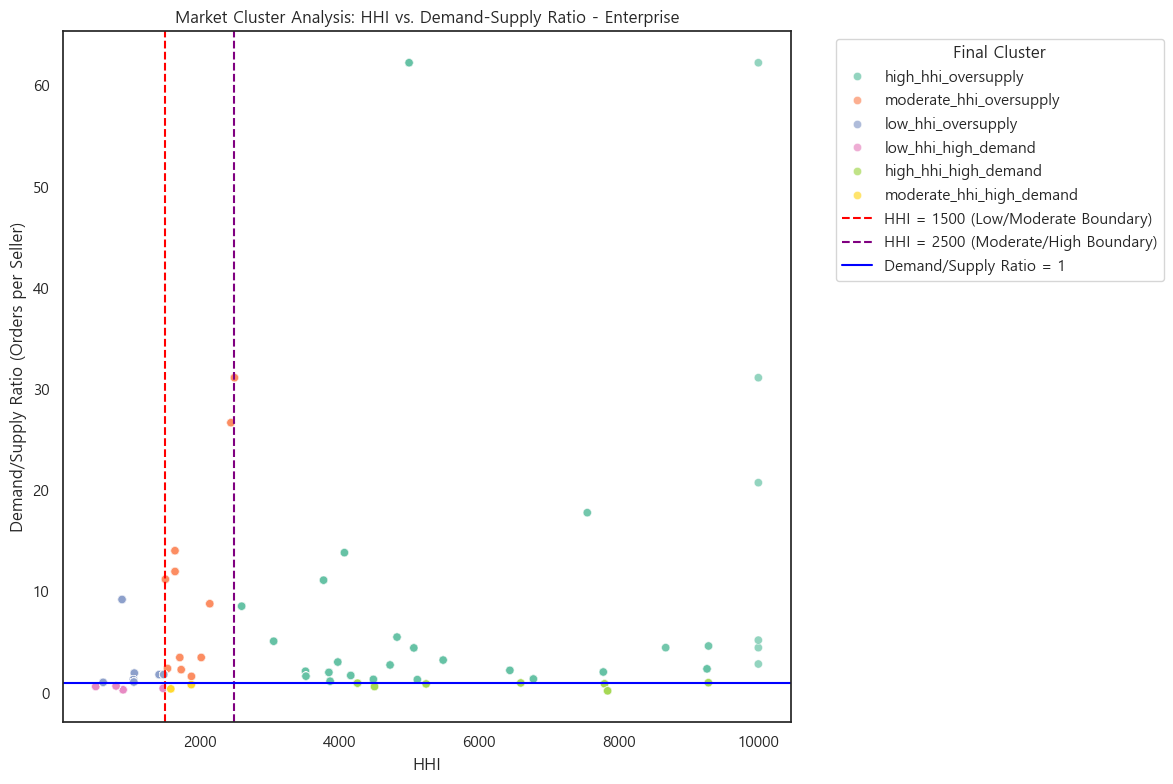

In [75]:
category_manager_matrix(ent_hhi_demand_supply, 'Enterprise')

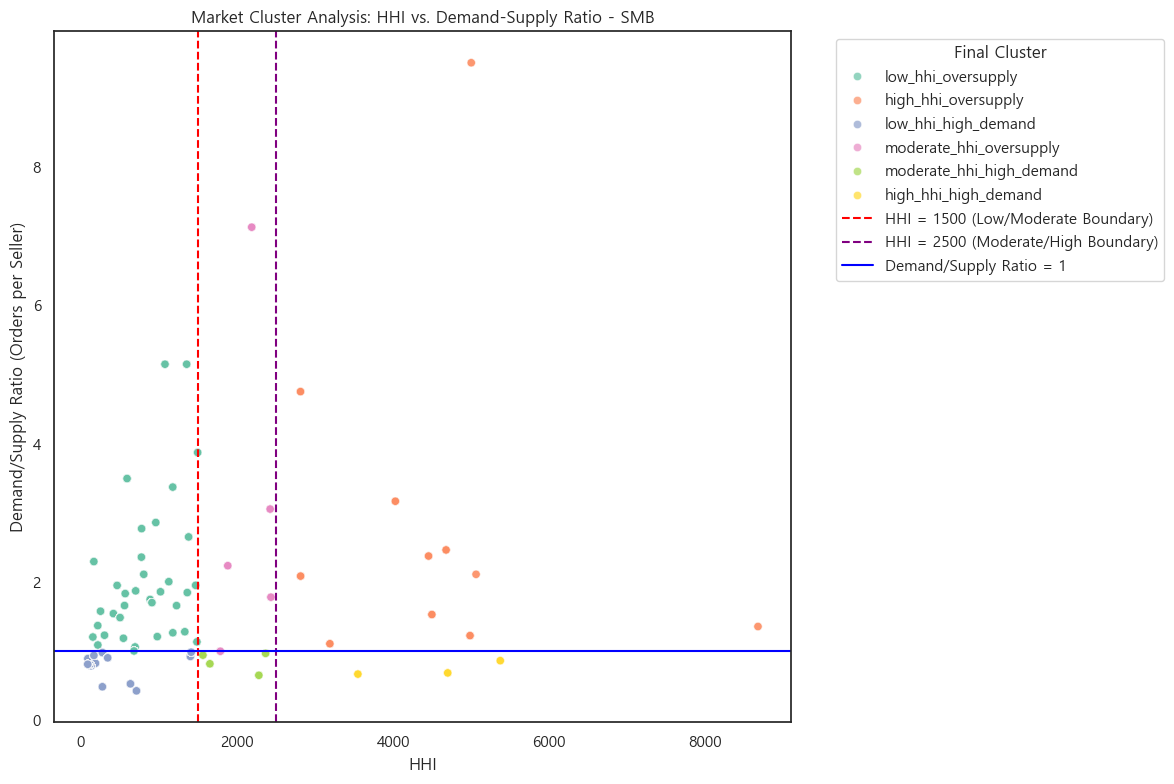

In [76]:
category_manager_matrix(smb_hhi_demand_supply, 'SMB')

# ✅ 대시보드용 파일
`category_matrix.csv` 생성

## 태블로 작업을 위한 매트릭스용 파일에 세그먼트 식별 컬럼 추가해서 csv 파일로 내보내기

In [ ]:
def add_segment (ent,smb):
    """
    태블로 전체에 세그먼트 필터를 걸기 위한 매트릭스 테이블에 세그먼트 추가 함수
    세그먼트 추가 후 두 테이블을 하나로 합쳐서 총 2개의 태블로용 csv파일을 생성
    
    :param ent: Enterprise
    :param smb: SMB
    """
    ent = ent.copy()
    smb = smb.copy()
    # Enterprise, SMB 테이블에 세그먼트 식별 컬럼 추가
    ent['segment'] = 'Enterprise'
    smb['segment'] = 'SMB'

    # 두 테이블 합치기
    final_combined_df = pd.concat(
        [ent, smb],
        ignore_index=True
    )

    # 행수 확인
    print(f"최종 행 수: {len(final_combined_df)}")
    
    return final_combined_df

## 매트릭스/클러스터 전용 테이블

In [78]:
final_hhi_demand_supply = add_segment(ent_hhi_demand_supply, smb_hhi_demand_supply)
final_hhi_demand_supply['segment'].value_counts()

최종 행 수: 6616


segment
SMB           5672
Enterprise     944
Name: count, dtype: int64

## csv 파일로 내보내기

In [80]:
# 매트릭스/클러스터 전용 데이블 내보내기
final_hhi_demand_supply.to_csv(
    'category_matrix.csv',
    index=False,
    encoding='utf-8-sig'
)
print("✅ category_matrix.csv 저장")

✅ category_matrix.csv 저장
